# Image generation using Distilled Flow Based Models


### Cell 1: Install Required Libraries


In [ ]:
# Cell 1: Install libraries
!pip install -q diffusers transformers accelerate safetensors

### Cell 2: Check Hardware Acceleration
Verifies GPU connection.

In [ ]:
# Cell 2: Verify GPU access
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device connected: {device}")

if device == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("Warning: GPU not detected. Please switch runtime to T4 GPU in Colab settings.")

Device connected: cuda
GPU Name: Tesla T4


Cell 2: Load SD-Turbo Pipeline (Fits in Free Tier VRAM)
Loads the official 0.9B parameter single-step generator directly onto the T4 GPU.

- Distilled-Flow Trajectory Model - SD Turbo

In [ ]:
# Cell 2: Load lightweight single-step generator
import torch
from diffusers import AutoPipelineForText2Image

device = "cuda" if torch.cuda.is_available() else "cpu"

# stabilityai/sd-turbo is a 0.9B parameter model that runs in 1 step
pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)

print(f"Single-step generator successfully loaded on {device}!")

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Single-step generator successfully loaded on cuda!


Cell 3: Execute Single-Step Trajectory (NFE = 1)
Generates an image setting num_inference_steps=1 and guidance_scale=0.0 (as distilled single-step models do not use CFG).

Generating image with single-step trajectory (NFE = 1)...


  0%|          | 0/1 [00:00<?, ?it/s]

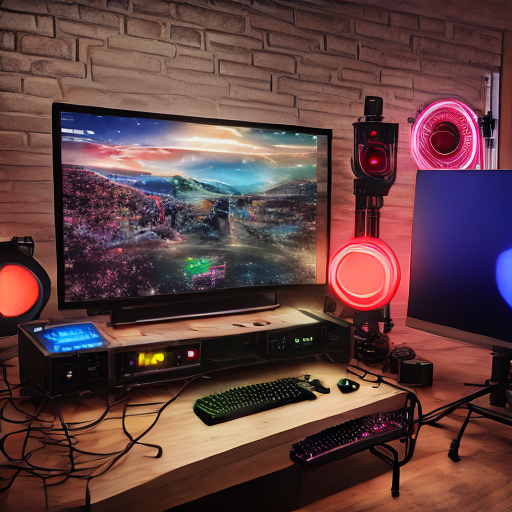

In [ ]:
# Cell 3: Run inference with NFE = 1
prompt = "A high quality photo of a modern streaming setup, neon lights, 8k"

print("Generating image with single-step trajectory (NFE = 1)...")

image = pipe(
    prompt=prompt,
    num_inference_steps=1,   # NFE = 1
    guidance_scale=0.0       # Distilled single-step models use guidance_scale = 0.0
).images[0]

# Display in Colab
image.save("turbo_output.png")
image

|Metric|,Standard Diffusion (Cell 1 Demo),|Distilled / Flow Trajectory (Cell 3 Demo)|
|-|-|-|
|Model ID|runwayml/stable-diffusion-v1-5|stabilityai/sd-turbo|
|Path Trajectory|Curved / Stochastic SDE|Straightened ODE Vector Field|
|Sampling Steps (NFE)|20 – 50 steps|1 step|
|CFG Scale (w)|7.5 (Requires 2 forward passes/step)|0.0 (Single forward pass)|
|Colab Execution Time|~3.5 seconds|~0.2 seconds|